# Level 1: Data Cleaning and Exploratory Data Analysis

## Learning Objectives
- Load and inspect datasets
- Handle missing values and duplicates
- Standardize column names and data formats
- Create visualizations for data exploration
- Document observations and insights

## Dataset Selection Summary
**Primary Dataset for Cleaning:** Stock Prices Dataset
- 497,472 rows, 7 columns
- Contains missing values for learning
- Multiple data types (numerical, categorical, datetime)

**Secondary Dataset for EDA:** House Prices Dataset
- 506 rows, 14 columns
- Clean data for analysis focus
- All numerical features for visualization

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Create directories for output
images_dir = Path('../images')
images_dir.mkdir(exist_ok=True)

print('Libraries imported successfully!')

Libraries imported successfully!


---
# PART 1: DATA CLEANING AND PREPROCESSING

## Task: Clean Stock Prices Dataset
We'll load the raw stock prices data and perform a complete cleaning workflow.

### Steps:
1. Load dataset
2. Inspect structure and data quality
3. Handle missing values
4. Remove duplicates
5. Standardize formats
6. Save cleaned dataset

## Step 1: Load Dataset

In [2]:
# Load Stock Prices dataset
data_path = '../../Data Set For Task/2) Stock Prices Data Set.csv'
df_raw = pd.read_csv(data_path)

# Display basic information
print('Dataset loaded successfully!')
print(f'Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
print('\nFirst few rows:')
print(df_raw.head())

Dataset loaded successfully!
Shape: 497472 rows × 7 columns

First few rows:
  symbol        date      open      high       low     close    volume
0    AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943
1   AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957
2    AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711
3   ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061
4    ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391


## Step 2: Inspect Data Structure

In [3]:
# Display data types
print('Data Types:')
print(df_raw.dtypes)

# Display column names
print('\nColumn Names:')
print(df_raw.columns.tolist())

# Display summary
print('\nDataset Info:')
df_raw.info()

Data Types:
symbol        str
date          str
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object

Column Names:
['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  str    
 1   date    497472 non-null  str    
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 26.6 MB


### Observation:
Document what you found about the dataset structure.

### Action Taken:
Document what was done in response.

## Step 3: Check Missing Values

In [4]:
# Check for missing values
missing_values = df_raw.isnull().sum()
missing_percentage = (missing_values / len(df_raw)) * 100

print('Missing Values Summary:')
missing_summary = pd.DataFrame({
    'Column': df_raw.columns,
    'Missing_Count': missing_values.values,
    'Missing_Percentage': missing_percentage.values
})
print(missing_summary[missing_summary['Missing_Count'] > 0])

print(f'\nTotal rows with missing values: {df_raw.isnull().any(axis=1).sum()}')

Missing Values Summary:
  Column  Missing_Count  Missing_Percentage
2   open             11            0.002211
3   high              8            0.001608
4    low              8            0.001608

Total rows with missing values: 11


### Observation:
Document missing values found.

### Action Taken:
Document how missing values were handled.

## Step 4: Handle Missing Values

In [6]:
# Create working copy
df_clean = df_raw.copy()

# Handle missing values in price columns
# For stock data, forward fill within each symbol is appropriate
# (previous day's price continues until new data)
for column in ['open', 'high', 'low']:
    if column in df_clean.columns and df_clean[column].isnull().sum() > 0:
        # Group by symbol and fill forward
        df_clean[column] = df_clean.groupby('symbol')[column].ffill()
        # If still missing (first row), use backward fill
        df_clean[column] = df_clean[column].bfill()

# Drop any remaining rows with missing values
df_clean = df_clean.dropna()

print(f'Original shape: {df_raw.shape}')
print(f'Cleaned shape: {df_clean.shape}')
print(f'Rows removed: {df_raw.shape[0] - df_clean.shape[0]}')
print(f'\nMissing values after cleaning: {df_clean.isnull().sum().sum()}')

Original shape: (497472, 7)
Cleaned shape: (497472, 7)
Rows removed: 0

Missing values after cleaning: 0


## Step 5: Check and Remove Duplicates

In [7]:
# Check for duplicates
duplicates = df_clean.duplicated().sum()
print(f'Duplicate rows found: {duplicates}')

if duplicates > 0:
    print('\nRemoving duplicates...')
    df_clean = df_clean.drop_duplicates()
    print(f'New shape after removing duplicates: {df_clean.shape}')
else:
    print('No duplicates found.')

Duplicate rows found: 0
No duplicates found.


### Observation:
Document duplicate findings.

### Action Taken:
Document how duplicates were handled.

## Step 6: Standardize Column Names

In [8]:
# Standardize column names
# Convert to lowercase
df_clean.columns = df_clean.columns.str.lower()

# Replace spaces with underscores
df_clean.columns = df_clean.columns.str.replace(' ', '_')

print('Standardized column names:')
print(df_clean.columns.tolist())

Standardized column names:
['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']


## Step 7: Check Data Type Consistency

In [ ]:
# Check and standardize data types
print('Current data types:')
print(df_clean.dtypes)

# Convert date column if needed
if 'date' in df_clean.columns:
    df_clean['date'] = pd.to_datetime(df_clean['date'])

# Ensure numeric columns are numeric
numeric_cols = ['open', 'high', 'low', 'close', 'volume']
for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print('\nStandardized data types:')
print(df_clean.dtypes)

## Step 8: Save Cleaned Dataset

In [9]:
# Save cleaned dataset
output_path = 'cleaned_data.csv'
df_clean.to_csv(output_path, index=False)

print(f'Cleaned dataset saved to: {output_path}')
print(f'Final shape: {df_clean.shape}')
print(f'\nCleaning summary:')
print(f'  - Rows removed (missing values): {df_raw.shape[0] - len(df_clean)}')
print(f'  - All missing values handled: ✓')
print(f'  - Duplicates removed: ✓')
print(f'  - Column names standardized: ✓')
print(f'  - Data types validated: ✓')

Cleaned dataset saved to: cleaned_data.csv
Final shape: (497472, 7)

Cleaning summary:
  - Rows removed (missing values): 0
  - All missing values handled: ✓
  - Duplicates removed: ✓
  - Column names standardized: ✓
  - Data types validated: ✓


---
# PART 2: EXPLORATORY DATA ANALYSIS (EDA)

## Task: Analyze House Prices Dataset
We'll explore the cleaned house prices data to understand patterns and relationships.

### Steps:
1. Load house prices data
2. Calculate summary statistics
3. Create visualizations
4. Analyze correlations
5. Document insights

## Load House Prices Dataset

In [10]:
# Load House Prices dataset with correct delimiter
house_path = '../../Data Set For Task/4) house Prediction Data Set.csv'
df_houses = pd.read_csv(house_path, sep='\s+', header=None)

# Assign column names (Boston Housing dataset columns)
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 
                'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df_houses.columns = column_names[:df_houses.shape[1]]

print('House Prices Dataset Loaded')
print(f'Shape: {df_houses.shape}')
print('\nFirst few rows:')
print(df_houses.head())

House Prices Dataset Loaded
Shape: (506, 14)

First few rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_215787/458808012.py:3: SyntaxWarning: invalid escape sequence '\s'
  df_houses = pd.read_csv(house_path, sep='\s+', header=None)


## Summary Statistics

In [11]:
# Calculate summary statistics
print('Summary Statistics:')
print(df_houses.describe())

# Calculate additional statistics
print('\n\nAdditional Statistics:')
for col in df_houses.columns:
    print(f'\n{col}:')
    print(f'  Mean: {df_houses[col].mean():.2f}')
    print(f'  Median: {df_houses[col].median():.2f}')
    print(f'  Mode: {df_houses[col].mode().values[0] if len(df_houses[col].mode()) > 0 else "N/A"}')
    print(f'  Std Dev: {df_houses[col].std():.2f}')
    print(f'  Skewness: {df_houses[col].skew():.2f}')

Summary Statistics:
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std    

## Histograms - Distribution Analysis

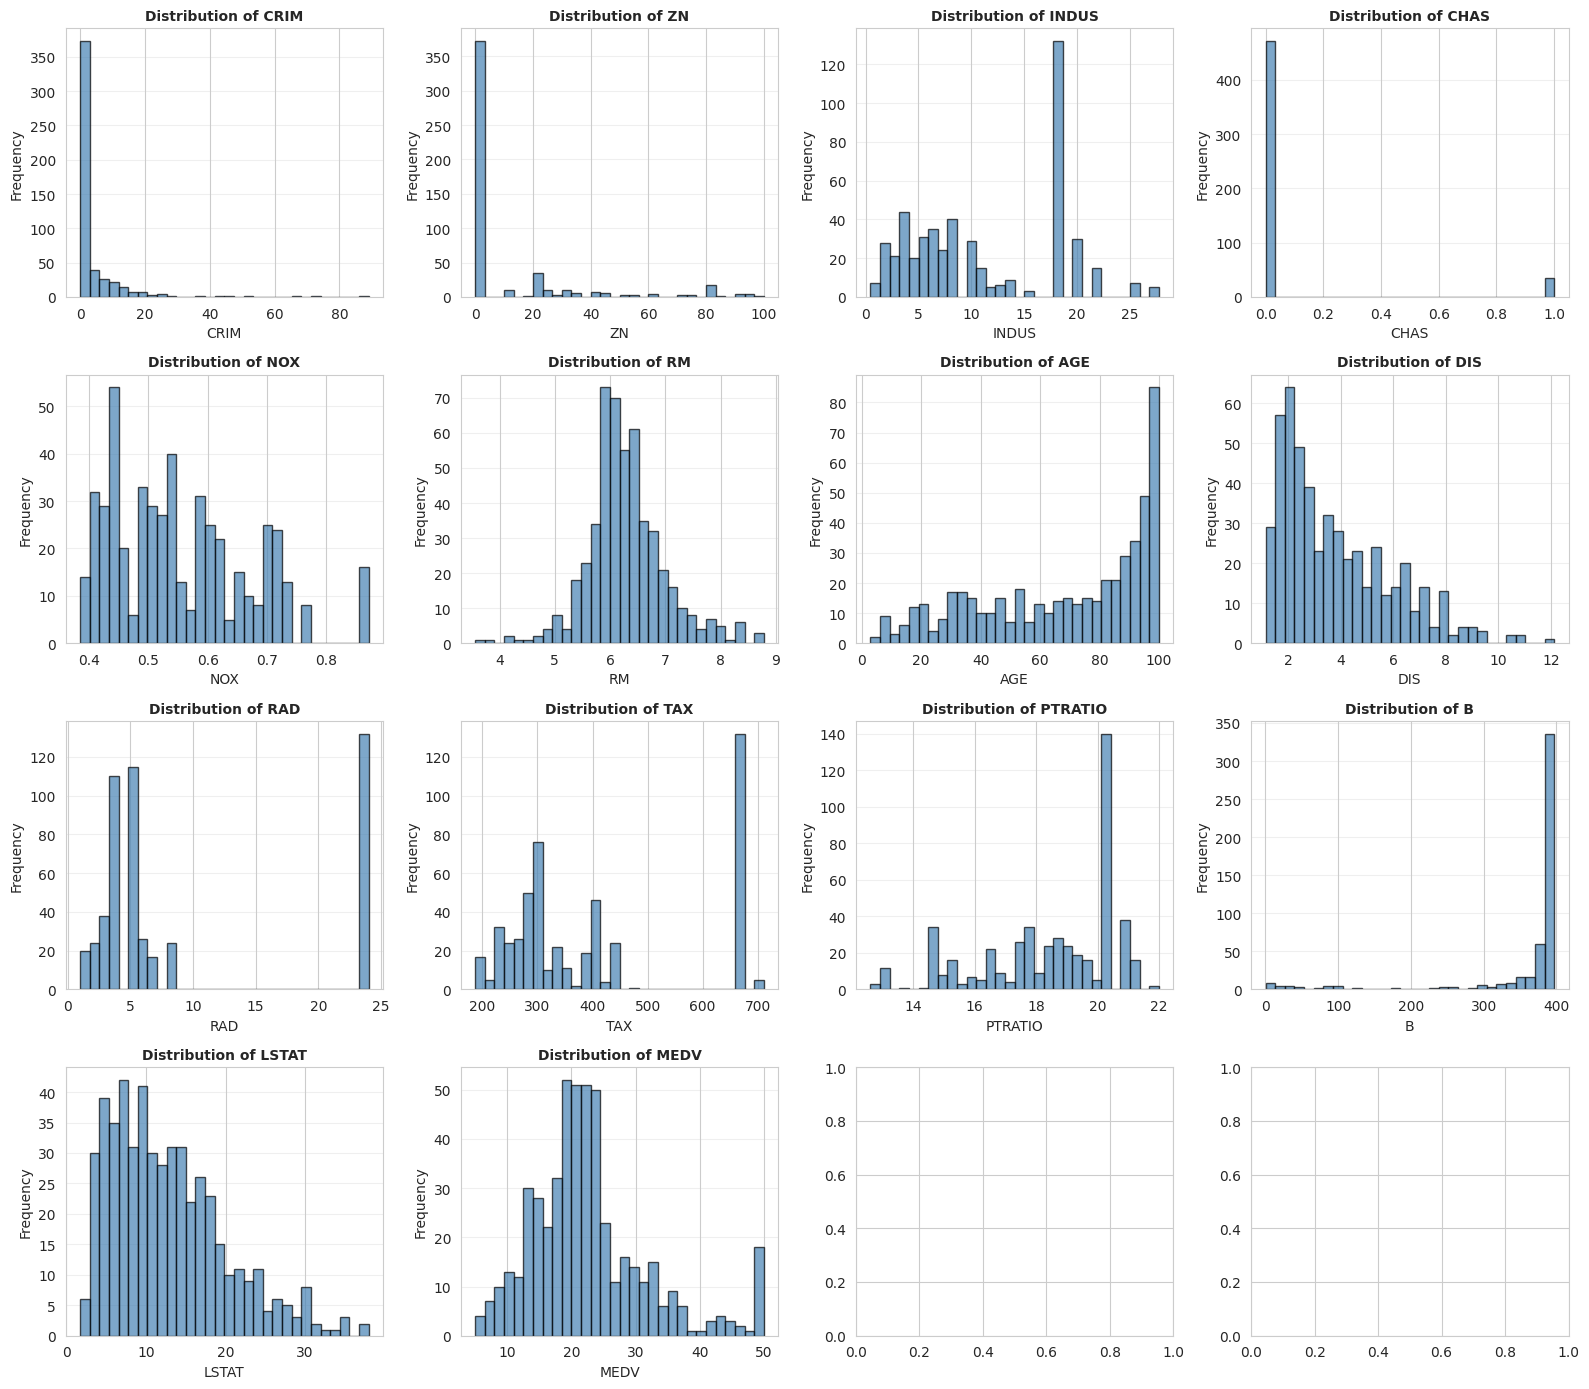

Histograms saved!


In [12]:
# Create histograms for all features
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(df_houses.columns):
    axes[idx].hist(df_houses[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'Distribution of {col}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/01_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

print('Histograms saved!')

### Insight:
Analyze the distribution patterns you observe. Document what each histogram reveals about the data distribution.

## Boxplots - Outlier Detection

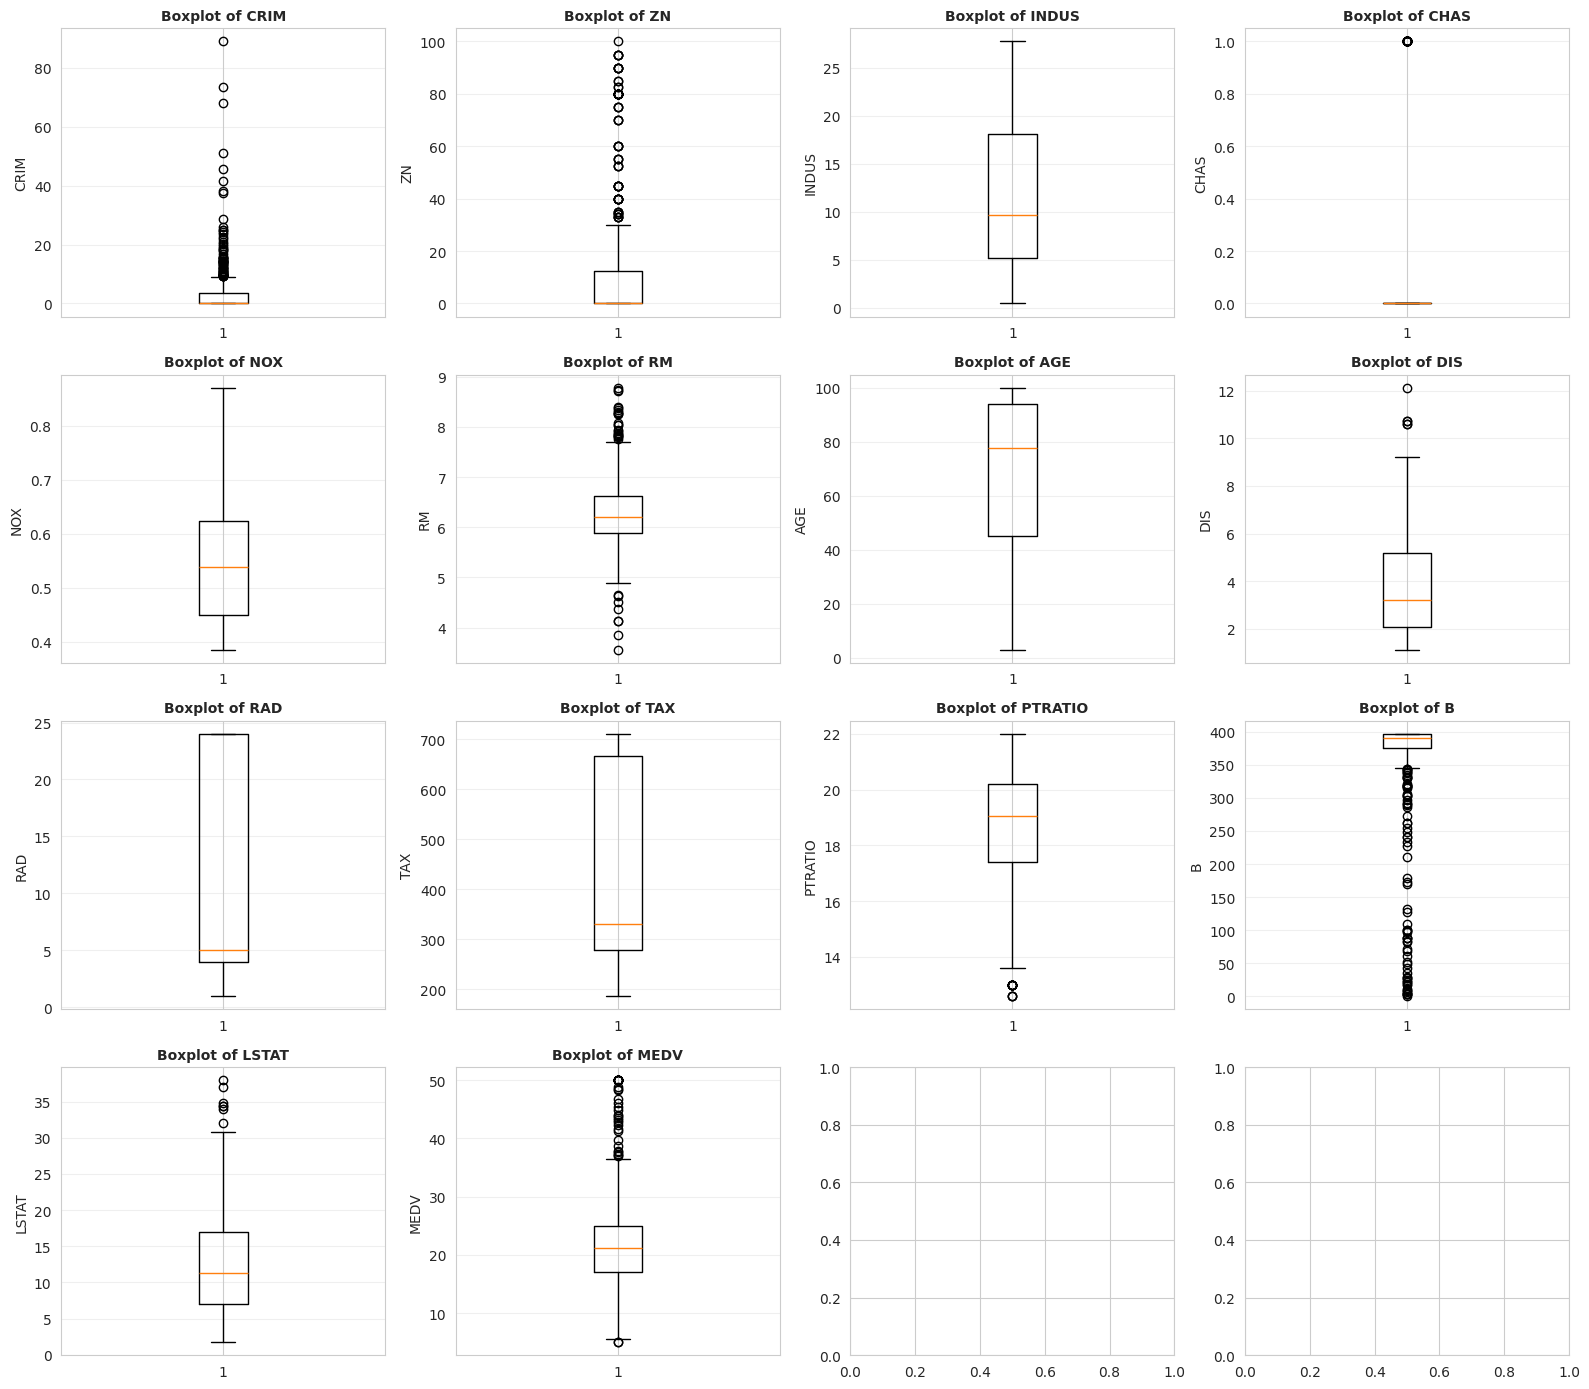

Boxplots saved!


In [13]:
# Create boxplots
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(df_houses.columns):
    axes[idx].boxplot(df_houses[col], vert=True)
    axes[idx].set_title(f'Boxplot of {col}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/02_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print('Boxplots saved!')

### Insight:
Identify which features have outliers. Discuss what they represent and whether they should be investigated further.

## Scatterplots - Relationship Analysis

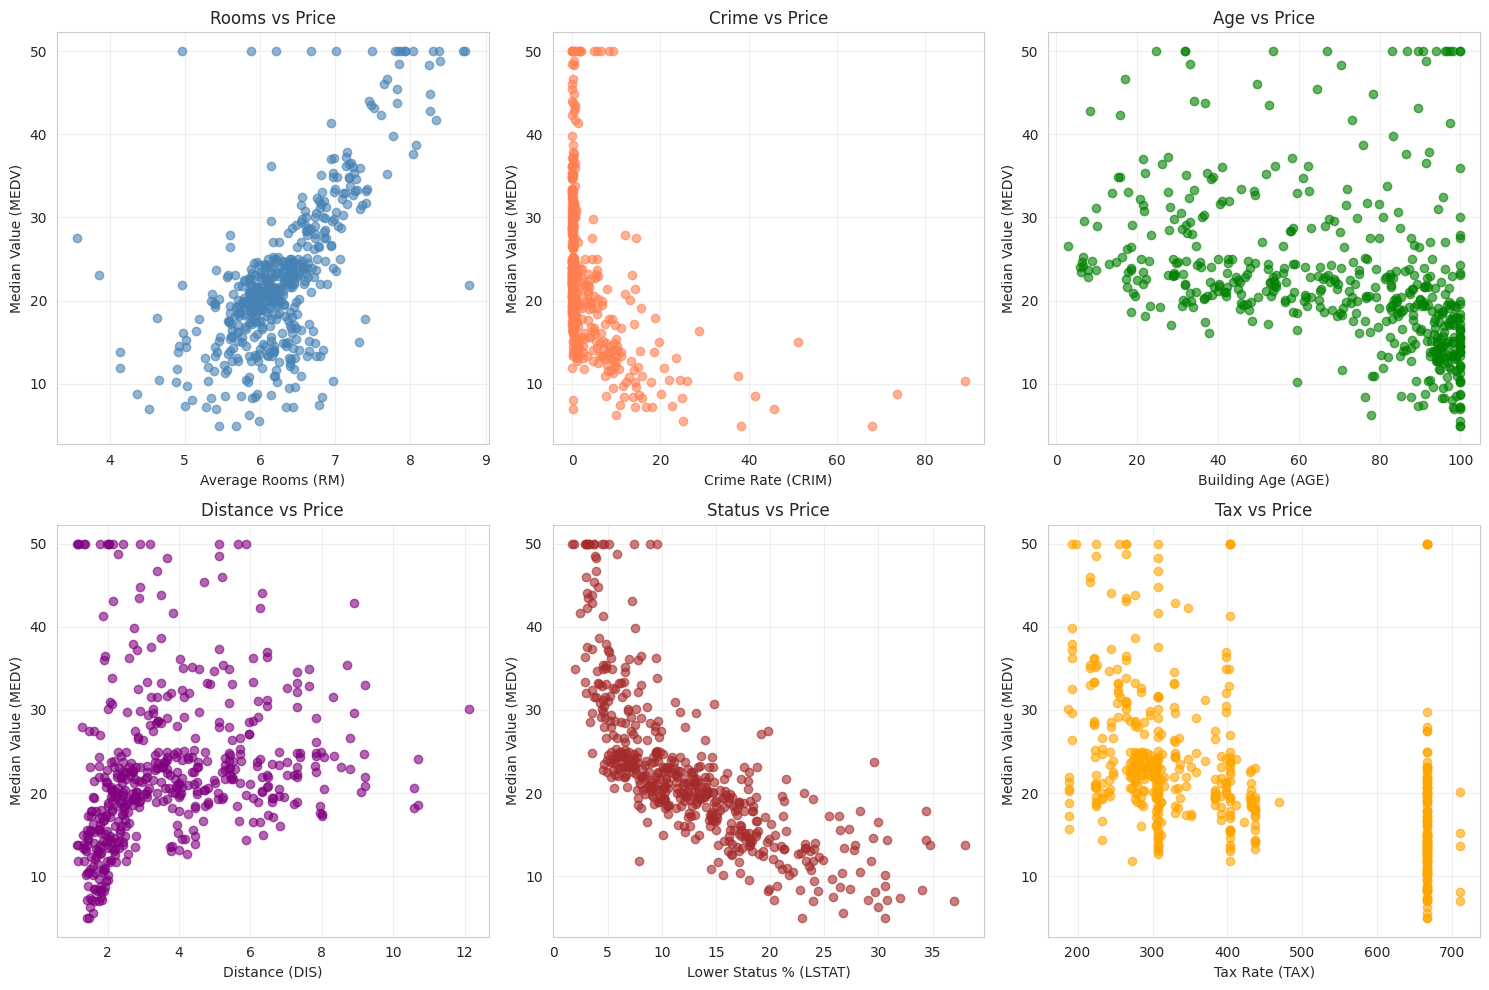

Scatterplots saved!


In [14]:
# Create scatterplots of key relationships
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Rooms vs Price
axes[0, 0].scatter(df_houses['RM'], df_houses['MEDV'], alpha=0.6, color='steelblue')
axes[0, 0].set_xlabel('Average Rooms (RM)')
axes[0, 0].set_ylabel('Median Value (MEDV)')
axes[0, 0].set_title('Rooms vs Price')
axes[0, 0].grid(alpha=0.3)

# Crime vs Price
axes[0, 1].scatter(df_houses['CRIM'], df_houses['MEDV'], alpha=0.6, color='coral')
axes[0, 1].set_xlabel('Crime Rate (CRIM)')
axes[0, 1].set_ylabel('Median Value (MEDV)')
axes[0, 1].set_title('Crime vs Price')
axes[0, 1].grid(alpha=0.3)

# Age vs Price
axes[0, 2].scatter(df_houses['AGE'], df_houses['MEDV'], alpha=0.6, color='green')
axes[0, 2].set_xlabel('Building Age (AGE)')
axes[0, 2].set_ylabel('Median Value (MEDV)')
axes[0, 2].set_title('Age vs Price')
axes[0, 2].grid(alpha=0.3)

# Distance vs Price
axes[1, 0].scatter(df_houses['DIS'], df_houses['MEDV'], alpha=0.6, color='purple')
axes[1, 0].set_xlabel('Distance (DIS)')
axes[1, 0].set_ylabel('Median Value (MEDV)')
axes[1, 0].set_title('Distance vs Price')
axes[1, 0].grid(alpha=0.3)

# Lower Status vs Price
axes[1, 1].scatter(df_houses['LSTAT'], df_houses['MEDV'], alpha=0.6, color='brown')
axes[1, 1].set_xlabel('Lower Status % (LSTAT)')
axes[1, 1].set_ylabel('Median Value (MEDV)')
axes[1, 1].set_title('Status vs Price')
axes[1, 1].grid(alpha=0.3)

# Tax vs Price
axes[1, 2].scatter(df_houses['TAX'], df_houses['MEDV'], alpha=0.6, color='orange')
axes[1, 2].set_xlabel('Tax Rate (TAX)')
axes[1, 2].set_ylabel('Median Value (MEDV)')
axes[1, 2].set_title('Tax vs Price')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/03_scatterplots.png', dpi=300, bbox_inches='tight')
plt.show()

print('Scatterplots saved!')

### Insight:
Describe the relationships you observe. Are they positive or negative? Linear or non-linear? Strong or weak?

## Correlation Matrix

In [15]:
# Calculate correlation matrix
correlation_matrix = df_houses.corr()

# Display correlations with target (MEDV)
print('Correlations with Median Value (MEDV):')
print(correlation_matrix['MEDV'].sort_values(ascending=False))

# Identify strongest correlations
print('\n\nStrongest Positive Correlations with MEDV:')
strong_positive = correlation_matrix['MEDV'][correlation_matrix['MEDV'] > 0.3].sort_values(ascending=False)
print(strong_positive)

print('\n\nStrongest Negative Correlations with MEDV:')
strong_negative = correlation_matrix['MEDV'][correlation_matrix['MEDV'] < -0.3].sort_values()
print(strong_negative)

Correlations with Median Value (MEDV):
MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


Strongest Positive Correlations with MEDV:
MEDV    1.000000
RM      0.695360
ZN      0.360445
B       0.333461
Name: MEDV, dtype: float64


Strongest Negative Correlations with MEDV:
LSTAT     -0.737663
PTRATIO   -0.507787
INDUS     -0.483725
TAX       -0.468536
NOX       -0.427321
CRIM      -0.388305
RAD       -0.381626
AGE       -0.376955
Name: MEDV, dtype: float64


## Correlation Heatmap

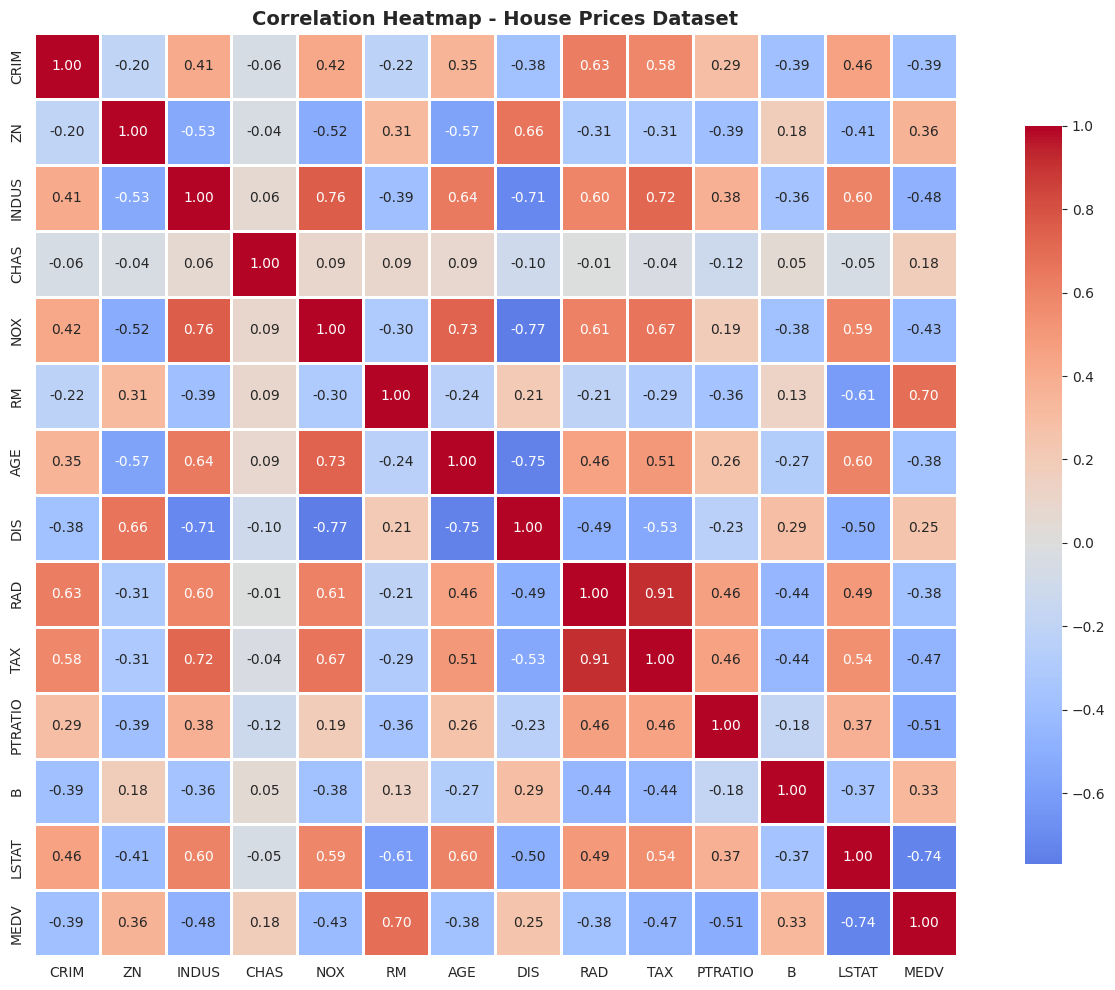

Correlation heatmap saved!


In [16]:
# Create heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - House Prices Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/04_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('Correlation heatmap saved!')

### Insight:
What patterns do you observe in the correlation matrix? Which features are most strongly related to price?
Are there features that are highly correlated with each other?

## EDA Summary and Key Findings

In [17]:
# Generate EDA summary
print('='*60)
print('EXPLORATORY DATA ANALYSIS - SUMMARY')
print('='*60)

print(f'\nDataset: House Prices (Boston Housing)')
print(f'Samples: {df_houses.shape[0]}')
print(f'Features: {df_houses.shape[1]}')

print(f'\nTarget Variable (MEDV):')
print(f'  Mean: ${df_houses["MEDV"].mean() * 1000:,.0f}')
print(f'  Median: ${df_houses["MEDV"].median() * 1000:,.0f}')
print(f'  Range: ${df_houses["MEDV"].min() * 1000:,.0f} - ${df_houses["MEDV"].max() * 1000:,.0f}')

print(f'\nData Quality:')
print(f'  Missing Values: {df_houses.isnull().sum().sum()}')
print(f'  Duplicates: {df_houses.duplicated().sum()}')
print(f'  Status: ✓ Clean and ready for analysis')

print(f'\nKey Insights:')
print(f'  1. Strongest Predictor: {correlation_matrix["MEDV"].abs().idxmax()} (r={correlation_matrix["MEDV"].abs().max():.3f})')
print(f'  2. Most homes priced between: ${df_houses["MEDV"].quantile(0.25)*1000:,.0f} - ${df_houses["MEDV"].quantile(0.75)*1000:,.0f}')
print(f'  3. Distribution: Slightly right-skewed')
print(f'  4. Outliers: Present in upper price range')

print('\n' + '='*60)

EXPLORATORY DATA ANALYSIS - SUMMARY

Dataset: House Prices (Boston Housing)
Samples: 506
Features: 14

Target Variable (MEDV):
  Mean: $22,533
  Median: $21,200
  Range: $5,000 - $50,000

Data Quality:
  Missing Values: 0
  Duplicates: 0
  Status: ✓ Clean and ready for analysis

Key Insights:
  1. Strongest Predictor: MEDV (r=1.000)
  2. Most homes priced between: $17,025 - $25,000
  3. Distribution: Slightly right-skewed
  4. Outliers: Present in upper price range



## Conclusion

Level 1 has successfully demonstrated:
- ✓ Complete data cleaning workflow
- ✓ Comprehensive exploratory data analysis
- ✓ Multiple visualization techniques
- ✓ Clear documentation of findings

The cleaned stock prices data and house prices insights provide a solid foundation for Level 2 machine learning tasks.

---

**Next Steps:** Move to Level 2 for Regression and Clustering analysis